# Global Earthquakes M≥4.0

Reads from `quakes.sqlite`, populated by `fetch_quakes.py` (USGS FDSN catalog).

Pre-1965 data is sparse globally; treat earlier years as undercounting reality.

Each plot is also saved to `figures/` as PNG. Re-execute the notebook to refresh them.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB = Path('quakes.sqlite')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
NETWORK_UPGRADE_YEAR = 2000  # Modern digital regional networks fully online; M4 detection stabilizes

def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=140, bbox_inches='tight', facecolor='white')

with sqlite3.connect(DB) as conn:
    df = pd.read_sql_query(
        'SELECT id, time_ms, mag, mag_type, lat, lon, depth_km, place '
        'FROM quakes ORDER BY time_ms',
        conn,
    )
df['time'] = pd.to_datetime(df['time_ms'], unit='ms', utc=True)
df['year'] = df['time'].dt.year

latest = df['time'].max()
current_year = int(latest.year)
year_start = pd.Timestamp(f'{current_year}-01-01', tz='UTC')
year_end = pd.Timestamp(f'{current_year + 1}-01-01', tz='UTC')
year_fraction = (latest - year_start) / (year_end - year_start)
print(f'Loaded {len(df):,} events, {df["time"].min():%Y-%m-%d} → {latest:%Y-%m-%d}')
print(f'Current year ({current_year}) is {year_fraction:.1%} complete — handled separately in plots.')
df.head()

Loaded 529,887 events, 1965-01-01 → 2026-05-08
Current year (2026) is 34.8% complete — handled separately in plots.


,id,time_ms,mag,mag_type,lat,lon,depth_km,place,time,year
0,ci3330737,-157737342220,4.46,ml,34.129333,-117.5090,3.310,"6km NW of Fontana, CA",1965-01-01 08:04:17.780000+00:00,1965
1,hv19650001,-157712534480,4.11,ml,19.814333,-155.3875,24.017,"24 km SW of Laup?hoehoe, Hawaii",1965-01-01 14:57:45.520000+00:00,1965
2,iscgem860696,-157688488640,5.64,mw,35.703000,4.3910,12.400,"13 km W of M’sila, Algeria",1965-01-01 21:38:31.360000+00:00,1965
3,iscgem860706,-157630541080,5.98,mw,19.246000,145.6160,131.600,"Maug Islands region, Northern Mariana Islands",1965-01-02 13:44:18.920000+00:00,1965
4,iscgem860737,-157465810500,5.76,mw,1.863000,127.3520,80.000,"74 km WNW of Tobelo, Indonesia",1965-01-04 11:29:49.500000+00:00,1965


## Magnitude vs Time

Each dot is one earthquake. M≥7.0 events highlighted. The grey shaded band on the right edge marks the partial current year.

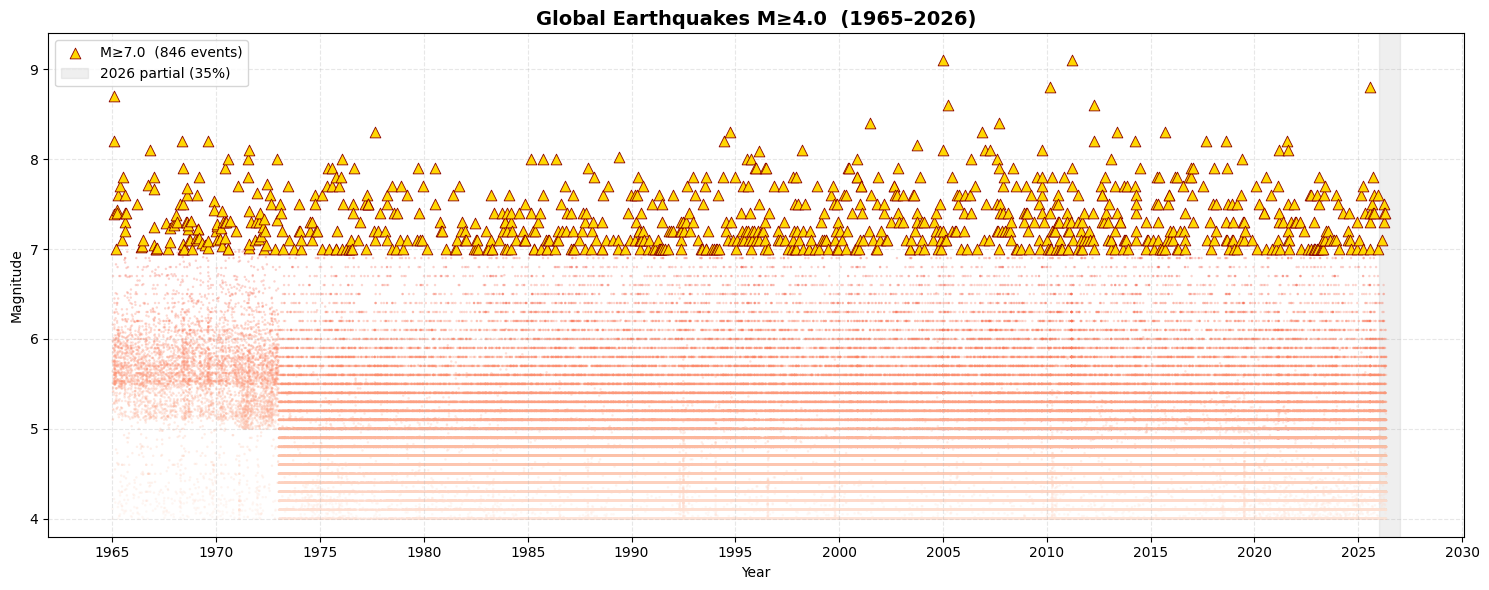

In [2]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.scatter(df['time'], df['mag'], c=df['mag'], cmap='Reds',
           alpha=0.25, s=3, linewidth=0)

major = df[df['mag'] >= 7.0]
ax.scatter(major['time'], major['mag'], c='gold', s=60, marker='^',
           edgecolors='darkred', linewidth=0.6, zorder=5,
           label=f'M≥7.0  ({len(major):,} events)')

ax.axvspan(year_start, year_end, color='grey', alpha=0.12, zorder=0,
           label=f'{current_year} partial ({year_fraction:.0%})')

ax.set_xlabel('Year')
ax.set_ylabel('Magnitude')
ax.set_title(f'Global Earthquakes M≥4.0  ({df["year"].min()}–{current_year})',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(3.8, df['mag'].max() + 0.3)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left')
plt.tight_layout()
save_fig(fig, '01_magnitude_vs_time.png')
plt.show()

## Yearly Counts by Magnitude Band

Pre-1965 numbers undercount due to sparse global instrumentation. The visible step-up around 1965–1973 is mostly improved coverage, not more quakes.

Trend line is a linear fit on the **post-network-upgrade era (≥2000)** only — once digital regional networks were fully online and M4 detection had largely stabilized. A full-span trend line would mostly track network-coverage gains rather than seismicity, so it's omitted.

The current year shows actual partial counts plus an annualized projection (lighter, hatched).

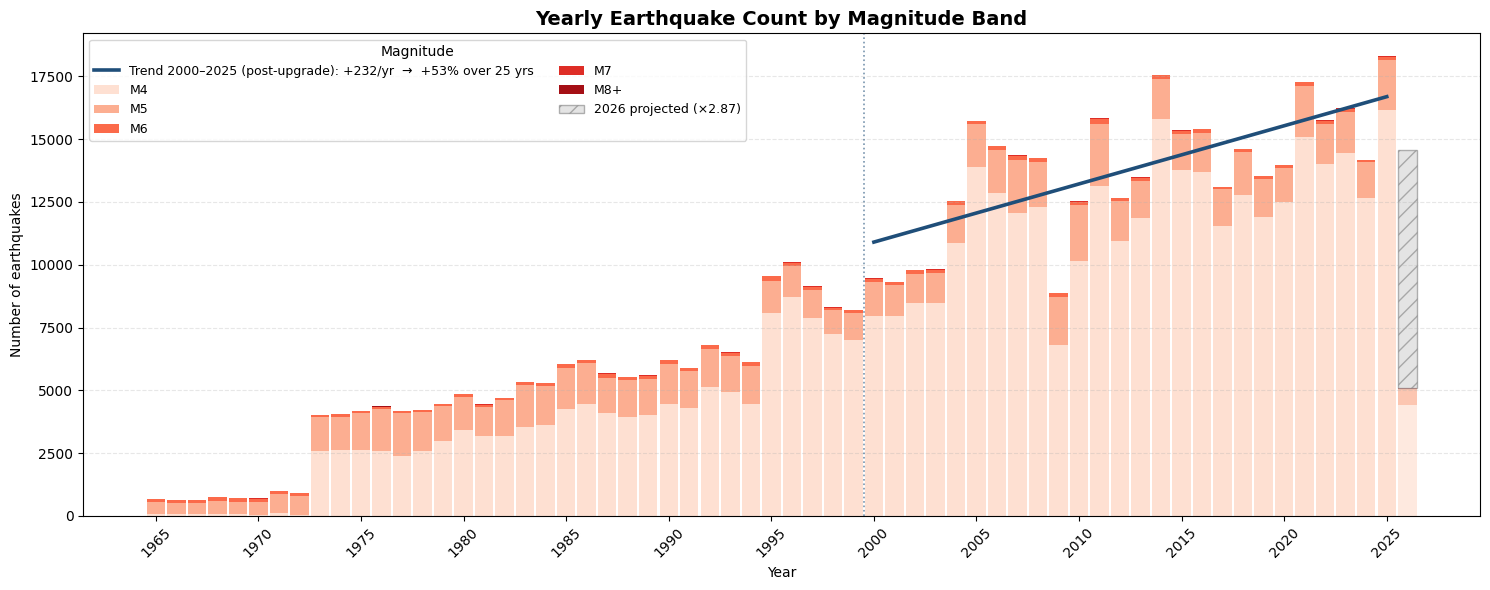

In [3]:
bands = [(4, 5, 'M4'), (5, 6, 'M5'), (6, 7, 'M6'), (7, 8, 'M7'), (8, 11, 'M8+')]
band_colors = ['#fee0d2', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']

by_year = pd.DataFrame({'year': sorted(df['year'].unique())}).set_index('year')
for lo, hi, label in bands:
    sel = df[(df['mag'] >= lo) & (df['mag'] < hi)]
    by_year[label] = sel.groupby('year').size()
by_year = by_year.fillna(0).astype(int)

complete_years = by_year.loc[by_year.index < current_year]
partial_row = by_year.loc[[current_year]] if current_year in by_year.index else None

fig, ax = plt.subplots(figsize=(15, 6))
year_to_x = {y: i for i, y in enumerate(by_year.index)}

bottom = np.zeros(len(complete_years))
for (lo, hi, label), color in zip(bands, band_colors):
    vals = complete_years[label].to_numpy()
    ax.bar([year_to_x[y] for y in complete_years.index], vals, bottom=bottom,
           color=color, width=0.9, label=label)
    bottom += vals

if partial_row is not None and year_fraction > 0:
    px = year_to_x[current_year]
    actual_total = int(partial_row.sum(axis=1).iloc[0])
    projected_total = actual_total / year_fraction
    bottom_p = 0.0
    for (lo, hi, label), color in zip(bands, band_colors):
        v = int(partial_row[label].iloc[0])
        ax.bar(px, v, bottom=bottom_p, color=color, width=0.9, alpha=0.7)
        bottom_p += v
    ax.bar(px, projected_total - actual_total, bottom=actual_total, color='lightgrey',
           width=0.9, alpha=0.6, hatch='//', edgecolor='grey',
           label=f'{current_year} projected (×{1/year_fraction:.2f})')

modern = complete_years.loc[complete_years.index >= NETWORK_UPGRADE_YEAR]
if len(modern) >= 5:
    m_yrs = modern.index.to_numpy()
    m_totals = modern.sum(axis=1).to_numpy()
    slope_m, intercept_m = np.polyfit(m_yrs, m_totals, 1)
    trend_m = slope_m * m_yrs + intercept_m
    n_yrs_m = m_yrs[-1] - m_yrs[0]
    pct_m = (trend_m[-1] - trend_m[0]) / trend_m[0] * 100
    ax.plot([year_to_x[y] for y in m_yrs], trend_m, color='#1f4e79',
            linewidth=2.6,
            label=(f'Trend {m_yrs[0]}–{m_yrs[-1]} (post-upgrade): '
                   f'{slope_m:+.0f}/yr  →  {pct_m:+.0f}% over {n_yrs_m} yrs'))

if NETWORK_UPGRADE_YEAR in year_to_x:
    ax.axvline(year_to_x[NETWORK_UPGRADE_YEAR] - 0.5, color='#1f4e79',
               linestyle=':', linewidth=1.2, alpha=0.6)

ax.set_xlabel('Year')
ax.set_ylabel('Number of earthquakes')
ax.set_title('Yearly Earthquake Count by Magnitude Band',
             fontsize=14, fontweight='bold')
ax.legend(title='Magnitude', loc='upper left', ncol=2, fontsize=9)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
xpos = np.arange(len(by_year))
ax.set_xticks(xpos[::5])
ax.set_xticklabels(by_year.index[::5], rotation=45)
plt.tight_layout()
save_fig(fig, '02_yearly_by_band.png')
plt.show()

## M≥7.0 Yearly Counts — the detection-bias control

Global instrumentation has been complete for M7+ for ~100 years, so this band is not affected by the same detection-improvement bias as the M4 band. If the trend in the stacked plot above were real seismicity, this line would rise too. If it stays flat, the apparent trend at lower magnitudes is detection, not actual quakes.

Red dashed line is the long-run mean across complete years; orange line is a 10-year rolling mean; black line is a linear fit on complete years only. The current year shows the actual partial count plus an annualized projection (hatched).

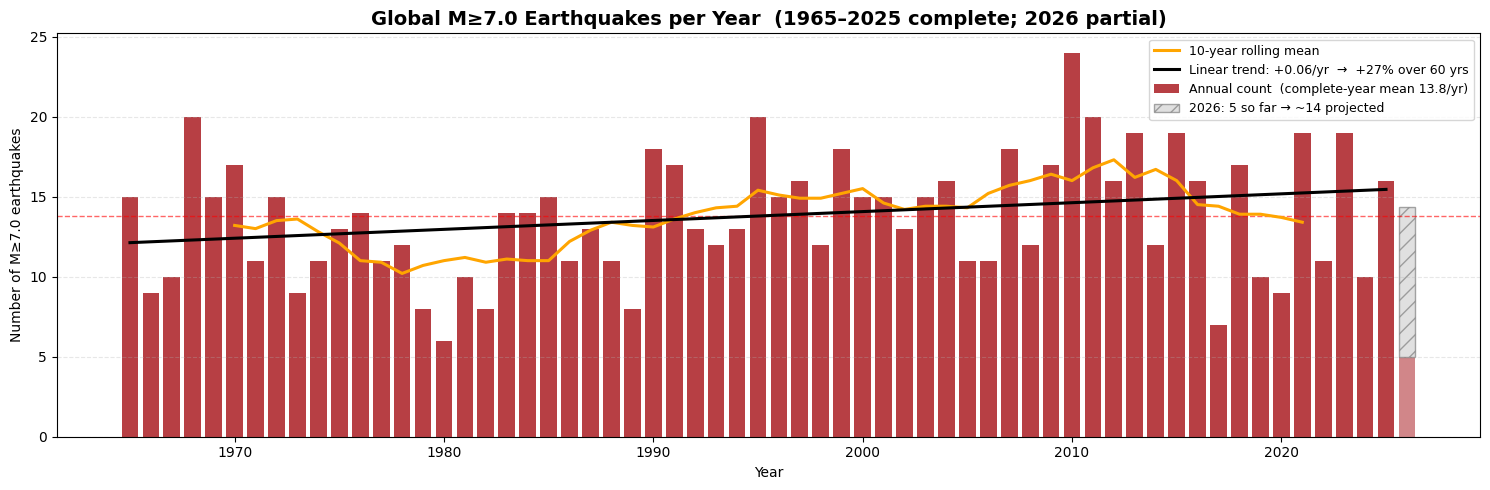

M≥7.0 stats over 61 complete years (1965–2025):
  mean:               13.79 per year
  median:             14.0 per year
  min:                6  (year 1980)
  max:                24  (year 2010)
  first-half mean:    12.43  (1965–1994)
  second-half mean:   15.10  (1995–2025)
  linear fit slope:   +0.055 events/year  (+3.3 over the span)
  2026 (partial, 34.8%): 5 events so far → annualized ~14


In [4]:
big = df[df['mag'] >= 7.0]
yearly_all = big.groupby('year').size()
yearly_all = yearly_all.reindex(
    range(yearly_all.index.min(), yearly_all.index.max() + 1), fill_value=0
)
yearly = yearly_all[yearly_all.index < current_year]

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(yearly.index, yearly.values, color='#a50f15', alpha=0.8,
       label=f'Annual count  (complete-year mean {yearly.mean():.1f}/yr)')

if current_year in yearly_all.index and year_fraction > 0:
    actual7 = int(yearly_all.loc[current_year])
    projected7 = actual7 / year_fraction
    ax.bar(current_year, actual7, color='#a50f15', alpha=0.5)
    ax.bar(current_year, projected7 - actual7, bottom=actual7,
           color='lightgrey', alpha=0.7, hatch='//', edgecolor='grey',
           label=f'{current_year}: {actual7} so far → ~{projected7:.0f} projected')

ax.axhline(yearly.mean(), color='red', linestyle='--', linewidth=1, alpha=0.6)
ax.plot(yearly.index, yearly.rolling(10, center=True).mean(),
        color='orange', linewidth=2.2, label='10-year rolling mean')

yi = yearly.index.to_numpy()
yv = yearly.values
slope7, intercept7 = np.polyfit(yi, yv, 1)
trend7 = slope7 * yi + intercept7
n_yrs = yi[-1] - yi[0]
pct7 = (trend7[-1] - trend7[0]) / trend7[0] * 100
ax.plot(yi, trend7, color='black', linewidth=2.2,
        label=f'Linear trend: +{slope7:.2f}/yr  →  +{pct7:.0f}% over {n_yrs} yrs')

ax.set_xlabel('Year')
ax.set_ylabel('Number of M≥7.0 earthquakes')
ax.set_title(f'Global M≥7.0 Earthquakes per Year  ({yi[0]}–{yi[-1]} complete; {current_year} partial)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
save_fig(fig, '03_m7_yearly.png')
plt.show()

n_years = len(yearly)
split = yearly.index.min() + n_years // 2
first_half = yearly[yearly.index < split].mean()
second_half = yearly[yearly.index >= split].mean()
print(f'M≥7.0 stats over {n_years} complete years ({yearly.index.min()}–{yearly.index.max()}):')
print(f'  mean:               {yearly.mean():.2f} per year')
print(f'  median:             {yearly.median():.1f} per year')
print(f'  min:                {yearly.min()}  (year {yearly.idxmin()})')
print(f'  max:                {yearly.max()}  (year {yearly.idxmax()})')
print(f'  first-half mean:    {first_half:.2f}  ({yearly.index.min()}–{split - 1})')
print(f'  second-half mean:   {second_half:.2f}  ({split}–{yearly.index.max()})')
print(f'  linear fit slope:   {slope7:+.3f} events/year  ({slope7 * n_yrs:+.1f} over the span)')
if current_year in yearly_all.index:
    actual7 = int(yearly_all.loc[current_year])
    print(f'  {current_year} (partial, {year_fraction:.1%}): {actual7} events so far '
          f'→ annualized ~{actual7 / year_fraction:.0f}')

## Magnitude Distribution

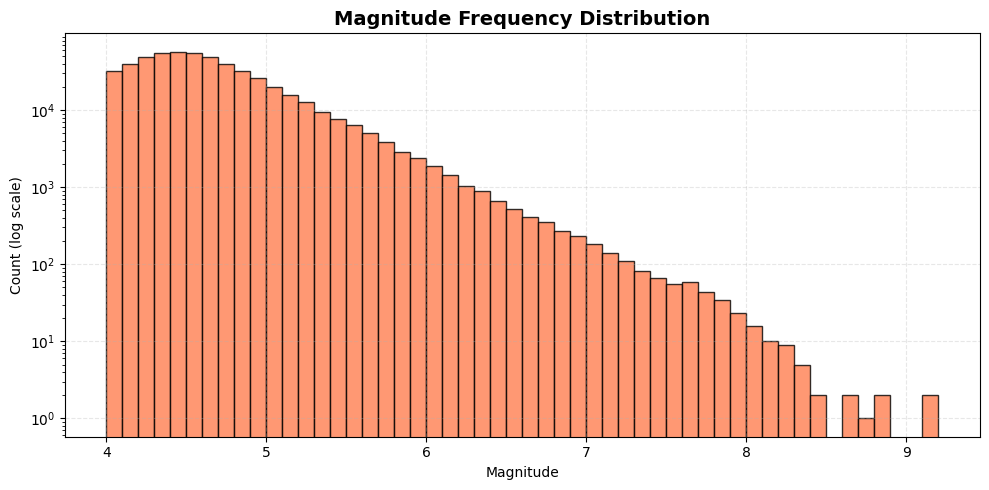

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['mag'], bins=np.arange(4.0, df['mag'].max() + 0.2, 0.1),
        color='coral', edgecolor='black', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Count (log scale)')
ax.set_title('Magnitude Frequency Distribution', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
save_fig(fig, '04_magnitude_distribution.png')
plt.show()

## Stats

In [6]:
complete_df = df[df['year'] < current_year]
partial_df = df[df['year'] == current_year]
n_complete_years = complete_df['year'].nunique()

print(f'Total events:          {len(df):,}  ({len(complete_df):,} in complete years + '
      f'{len(partial_df):,} in {current_year} partial)')
print(f'Complete-year range:   {complete_df["time"].min():%Y-%m-%d}  →  '
      f'{complete_df["time"].max():%Y-%m-%d}  ({n_complete_years} years)')
print(f'Partial year:          {current_year}  ({year_fraction:.1%} elapsed, '
      f'{len(partial_df):,} events so far)')
print(f'Magnitude range:       {df["mag"].min():.1f}  →  {df["mag"].max():.1f}')
print()
print('Counts by magnitude band (complete years):')
for lo, hi, label in bands:
    n = ((complete_df['mag'] >= lo) & (complete_df['mag'] < hi)).sum()
    rate = n / n_complete_years
    print(f'  {label:5s}  {n:>9,}    ({rate:>7.1f}/yr)')
print()
print('Top 10 largest events:')
top = df.nlargest(10, 'mag')[['time', 'mag', 'place']]
for _, row in top.iterrows():
    print(f'  {row["time"]:%Y-%m-%d}  M{row["mag"]:.1f}  {row["place"]}')

Total events:          529,887  (524,811 in complete years + 5,076 in 2026 partial)
Complete-year range:   1965-01-01  →  2025-12-31  (61 years)
Partial year:          2026  (34.8% elapsed, 5,076 events so far)
Magnitude range:       3.4  →  9.1

Counts by magnitude band (complete years):
  M4       430,940    ( 7064.6/yr)
  M5        85,390    ( 1399.8/yr)
  M6         7,639    (  125.2/yr)
  M7           792    (   13.0/yr)
  M8+           49    (    0.8/yr)

Top 10 largest events:
  2004-12-26  M9.1  2004 Sumatra - Andaman Islands Earthquake
  2011-03-11  M9.1  2011 Great Tohoku Earthquake, Japan
  2010-02-27  M8.8  2010 Maule, Chile Earthquake
  2025-07-29  M8.8  2025 Kamchatka Peninsula, Russia Earthquake
  1965-02-04  M8.7  1965 Western Aleutian Islands (Hawadax/Rat Islands) Earthquake
  2005-03-28  M8.6  78 km WSW of Singkil, Indonesia
  2012-04-11  M8.6  2012 Wharton Basin Earthquake
  2001-06-23  M8.4  6 km SSW of Atico, Peru
  2007-09-12  M8.4  122 km SW of Bengkulu, Indonesi